# Triad Region (NC) Real Estate: Identifying Undervalued Investment Opportunities

## Introduction

**Target Audience:** Small residential real estate investors in the Piedmont Triad 
region of North Carolina — specifically those pursuing fix-and-flip or buy-to-rent 
strategies with acquisition budgets under USD 1,000,000.

**Research Question:** Which zip codes in the Piedmont Triad offer the most favorable 
market conditions for small residential investors, and which active listings appear 
undervalued relative to their estimated fair market value and neighborhood fundamentals?

**Motivation:** The Piedmont Triad — anchored by Greensboro, Winston-Salem, and High 
Point — is one of North Carolina's most accessible housing markets, with median prices 
well below state and national averages. The region's economic base (Toyota, Honda 
Aircraft, FedEx, Wake Forest Baptist Health, and three major university systems) 
creates stable workforce rental demand, making it an attractive target for residential 
investors who manage their own portfolios.

This analysis takes a data-driven approach to answer the two questions every 
small investor asks: *where should I be looking?* and *is this specific property 
a good deal?* We address the first through zip-code-level market analysis combining 
RentCast market data with US Census demographics, and the second through a composite 
Investor Opportunity Score applied to 952 active listings across Greensboro and 
High Point.

**Project arc.** The midterm phase of this project built a heuristic composite 
"Investor Opportunity Score" combining five hand-weighted signals (price below 
zip median, price per sqft, age flag, bath-bed ratio, renter ratio) to rank 
listings. The final phase extends this work with two statistical models — a 
linear regression predicting listing price and a logistic regression classifying 
deal status — that test whether the midterm's intuitions actually predict 
statistical underpricing. SQL analysis is integrated throughout to support 
market-level interpretation and surface strategic findings about specific 
zip codes.

**Data Sources:**
- RentCast API — active listings and aggregate market statistics by zip code
- US Census Bureau ACS 5-year estimates — demographics and income by zip code  
- FRED (Federal Reserve) — 30-year fixed mortgage rate history

### Two distinct submarkets

Supplementary SQL analysis (`sql_queries.ipynb`) confirms that the Piedmont Triad 
presents two structurally different investment universes. Greensboro is the larger 
market (695 listings) with newer housing stock (avg year built 1989) and substantial 
multifamily inventory — 56% of listings carry an HOA, and property type composition 
is diversified (67% single-family, 21% townhouse, 12% condo). High Point is smaller 
(257 listings), older (avg year built 1977), and dominated by detached single-family 
homes (82% single-family, only 33% with HOA). This analysis treats the two cities as 
separate investment opportunities rather than a single regional market.

In [85]:
# Standard library
import os
import time
import json

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# API calls
import requests

# Environment variables
from dotenv import load_dotenv

# Census and FRED
from census import Census
from fredapi import Fred

# Load API keys from .env file in home directory
load_dotenv(dotenv_path=os.path.expanduser("~/.env"))

RENTCAST_KEY = os.getenv("RENTCAST_API_KEY")
CENSUS_KEY   = os.getenv("CENSUS_API_KEY")
FRED_KEY     = os.getenv("FRED_API_KEY")

# Sanity check — confirms keys loaded without printing actual values
print("Keys loaded:", all([RENTCAST_KEY, CENSUS_KEY, FRED_KEY]))

# Global plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Modeling

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler

Keys loaded: False


## Phase 1: Data Collection

Data is pulled from three sources:
- **RentCast API:** Active listings and market-level statistics for Piedmont Triad zip codes
- **US Census API:** Demographic and income data by zip code
- **FRED API:** Current and historical mortgage rate context

All data is saved to local variables after pulling to avoid re-hitting API rate limits 
during subsequent notebook runs.

In [31]:
# Piedmont Triad zip codes covering Greensboro, Winston-Salem, High Point,
# and surrounding communities in Guilford, Forsyth, and Davidson counties
piedmont_zips = [
    # Greensboro (Guilford County)
    "27401", "27403", "27405", "27406", "27407", "27408", "27409", "27410",
    # High Point (Guilford/Forsyth/Davidson)
    "27260", "27262", "27265",
    # Winston-Salem (Forsyth County)
    "27101", "27103", "27104", "27105", "27106", "27107", "27127",
    # Surrounding communities
    "27284", # Kernersville
    "27295", # Lexington
    "27292", # Lexington
    "27312", # Pittsboro area
    "27320", # Reidsville
    "27360", # Thomasville
]

print(f"Total zip codes to analyze: {len(piedmont_zips)}")

Total zip codes to analyze: 24


### 1.1 RentCast — Market Data by Zip Code

We pull aggregate market statistics for each zip code using the RentCast `/markets` 
endpoint. This gives us zip-level pricing, days on market, and inventory data that 
forms the backbone of our macro-level analysis.

In [32]:
# Load market data from CSV (originally pulled from RentCast API)
import ast

df_market = pd.read_csv("market_data_raw.csv", dtype={"zipCode": str})

# Parse the nested columns back from string to Python objects
for col in ["dataByPropertyType", "dataByBedrooms", "history"]:
    if col in df_market.columns:
        df_market[col] = df_market[col].apply(
            lambda x: ast.literal_eval(x) if pd.notna(x) else None
        )

print(f"Market data shape: {df_market.shape}")
print(df_market.head())

Market data shape: (24, 23)
  zipCode           lastUpdatedDate  averagePrice  medianPrice  minPrice  \
0   27401  2026-04-26T00:00:00.000Z        261018       185000     10000   
1   27403  2026-04-26T00:00:00.000Z        326228       274000     15000   
2   27405  2026-04-26T00:00:00.000Z        281958       269000     14000   
3   27406  2026-04-26T00:00:00.000Z        334136       285000     25000   
4   27407  2026-04-26T00:00:00.000Z        370007       255000     18000   

   maxPrice  averagePricePerSquareFoot  medianPricePerSquareFoot  \
0   5250000                     203.80                    194.63   
1    875000                     205.66                    210.69   
2   1870000                     172.36                    168.58   
3   8000000                     165.48                    163.64   
4   3750000                     214.65                    184.71   

   minPricePerSquareFoot  maxPricePerSquareFoot  ...  maxSquareFootage  \
0                  92.92        

### 1.2 RentCast — Active Listings

We pull active for-sale listings for the three main Piedmont Triad cities. Because 
RentCast limits results per call, we use a while loop with an offset parameter to 
paginate through all available listings — ensuring we capture the full dataset rather 
than just the first page of results.

In [33]:
# Load listings from CSV (originally pulled from RentCast API)
import ast

df_listings = pd.read_csv("listings_raw.csv", dtype={"zipCode": str})

# Parse the nested columns back from string to Python objects
for col in ["hoa", "history", "listingAgent", "listingOffice"]:
    if col in df_listings.columns:
        df_listings[col] = df_listings[col].apply(
            lambda x: ast.literal_eval(x) if pd.notna(x) else None
        )

print(f"Listings dataframe shape: {df_listings.shape}")
print(df_listings.head())

Listings dataframe shape: (1202, 33)
                                         id  \
0  5200-Postbridge-Dr,-Greensboro,-NC-27407   
1  4704-Postbridge-Dr,-Greensboro,-NC-27407   
2  4714-Postbridge-Dr,-Greensboro,-NC-27407   
3      4102-Dunley-Ct,-Greensboro,-NC-27407   
4     4113-Tansley-Ct,-Greensboro,-NC-27407   

                           formattedAddress        addressLine1 addressLine2  \
0  5200 Postbridge Dr, Greensboro, NC 27407  5200 Postbridge Dr          NaN   
1  4704 Postbridge Dr, Greensboro, NC 27407  4704 Postbridge Dr          NaN   
2  4714 Postbridge Dr, Greensboro, NC 27407  4714 Postbridge Dr          NaN   
3      4102 Dunley Ct, Greensboro, NC 27407      4102 Dunley Ct          NaN   
4     4113 Tansley Ct, Greensboro, NC 27407     4113 Tansley Ct          NaN   

         city state  stateFips zipCode    county  countyFips  ...   mlsName  \
0  Greensboro    NC         37   27407  Guilford          81  ...  TriadMLS   
1  Greensboro    NC         37   27407  G

### 1.3 Saving Raw Data Locally

All API data is saved to CSV immediately after pulling to preserve our API quota. 
All subsequent analysis reads from these local files rather than re-calling the API.

In [34]:
# Save raw data to CSV — do this immediately to preserve API quota
df_market.to_csv("market_data_raw.csv", index=False)
df_listings.to_csv("listings_raw.csv", index=False)

print("Saved:")
print(f"  market_data_raw.csv     — {df_market.shape[0]} rows, {df_market.shape[1]} cols")
print(f"  listings_raw.csv        — {df_listings.shape[0]} rows, {df_listings.shape[1]} cols")

Saved:
  market_data_raw.csv     — 24 rows, 23 cols
  listings_raw.csv        — 1202 rows, 33 cols


### 1.4 Census API — Demographics by Zip Code

We pull median household income, total population, and housing unit counts for each 
Piedmont Triad zip code from the US Census Bureau's American Community Survey (ACS) 
5-year estimates. This enriches our listing-level analysis with neighborhood 
socioeconomic context relevant to rental demand and long-term appreciation.

In [35]:
# Load Census demographics from CSV (originally pulled from Census ACS API)
df_census = pd.read_csv("census_data_raw.csv", dtype={"zipCode": str})

print(f"Census data shape: {df_census.shape}")
print(df_census.head())

Census data shape: (24, 8)
  zipCode  median_household_income  total_population  total_housing_units  \
0   27401                    44524             21788                 9650   
1   27403                    56722             20675                 8671   
2   27405                    46498             52525                21762   
3   27406                    56748             63661                28080   
4   27407                    59308             52583                23861   

   owner_occupied_units  renter_occupied_units  renter_ratio  income_missing  
0                  2876                   5228      0.541762           False  
1                  4083                   3617      0.417138           False  
2                  9767                  10171      0.467374           False  
3                 14276                  11698      0.416595           False  
4                 10350                  11555      0.484263           False  


### 1.5 FRED API — Mortgage Rate Context

We pull the 30-year fixed mortgage rate from FRED to provide macroeconomic context 
for our analysis. Rising rates compress buyer purchasing power and affect both 
fix-and-flip timelines and buy-to-rent cap rates — directly relevant to our 
target audience's investment decisions.

In [36]:
# Load mortgage rates from CSV (originally pulled from FRED API)
df_rates = pd.read_csv("mortgage_rates_raw.csv", parse_dates=["date"])

print(f"Mortgage rate data shape: {df_rates.shape}")
print(f"Date range: {df_rates['date'].min()} to {df_rates['date'].max()}")
print(f"Current rate: {df_rates['rate_30yr_fixed'].iloc[-1]:.2f}%")
print(df_rates.tail())

Mortgage rate data shape: (173, 2)
Date range: 2023-01-05 00:00:00 to 2026-04-23 00:00:00
Current rate: 6.23%
          date  rate_30yr_fixed
168 2026-03-26             6.38
169 2026-04-02             6.46
170 2026-04-09             6.37
171 2026-04-16             6.30
172 2026-04-23             6.23


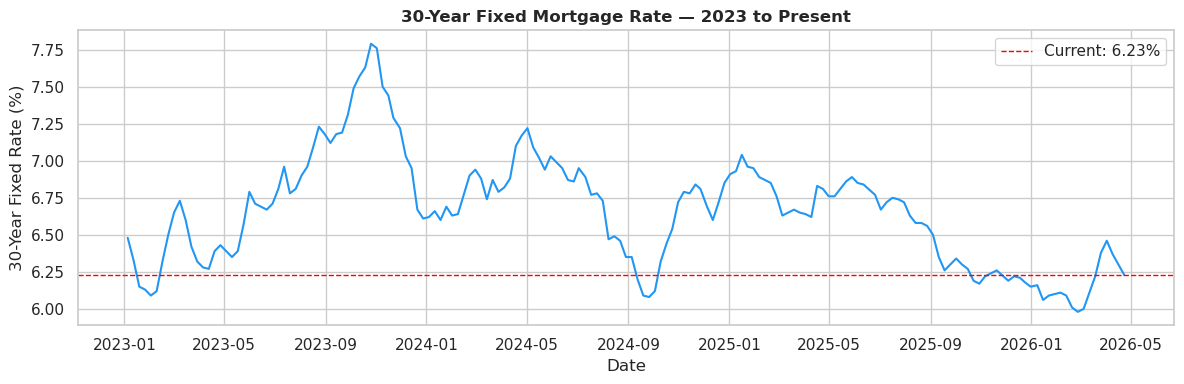

In [37]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_rates["date"], df_rates["rate_30yr_fixed"], 
        color="#2196F3", linewidth=1.5)
ax.axhline(y=df_rates["rate_30yr_fixed"].iloc[-1], 
           color="red", linestyle="--", linewidth=1,
           label=f"Current: {df_rates['rate_30yr_fixed'].iloc[-1]:.2f}%")
ax.set_xlabel("Date")
ax.set_ylabel("30-Year Fixed Rate (%)")
ax.set_title("30-Year Fixed Mortgage Rate — 2023 to Present", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("mortgage_rates.png", bbox_inches="tight", dpi=150)
plt.show()

**Context:** The 30-year fixed mortgage rate peaked above 7% in late 2023 
and has trended downward to 6.23% as of April 2026. For a small investor 
purchasing a median-priced 299,000 property with 20% down, each 1% 
rate reduction saves approximately 150/month in carrying costs — 
directly affecting cash-on-cash return for buy-to-rent investors.

## Phase 2: Data Quality Assessment

Before analysis, we systematically inspect each dataset for missing values, 
outliers, and validity issues. Decisions made here directly affect the integrity 
of our EDA — poor data quality left unchecked leads to misleading conclusions.

We assess three dimensions:
- **Completeness:** Are there missing values, and how many?
- **Validity:** Are values within plausible ranges?
- **Consistency:** Do values across datasets align logically?

In [38]:
# ── Listings: missingness overview ───────────────────────────────────────────
print("=" * 55)
print("LISTINGS MISSINGNESS")
print("=" * 55)

missing_listings = (
    df_listings.isnull().sum()
    .rename("missing_count")
    .to_frame()
)
missing_listings["pct_missing"] = (
    missing_listings["missing_count"] / len(df_listings) * 100
).round(1)

# Only show columns that have at least some missing data
print(missing_listings[missing_listings["missing_count"] > 0]
      .sort_values("pct_missing", ascending=False)
      .to_string())

print(f"\nTotal listings: {len(df_listings)}")

# ── Market data: missingness overview ─────────────────────────────────────────
print("\n" + "=" * 55)
print("MARKET DATA MISSINGNESS")
print("=" * 55)
missing_market = df_market.isnull().sum()
print(missing_market[missing_market > 0].to_string()
      if missing_market.sum() > 0 else "No missing values.")

# ── Census: missingness overview ──────────────────────────────────────────────
print("\n" + "=" * 55)
print("CENSUS DATA MISSINGNESS")
print("=" * 55)
missing_census = df_census.isnull().sum()
print(missing_census[missing_census > 0].to_string()
      if missing_census.sum() > 0 else "No missing values.")
print(f"\nZip codes with missing income: {df_census['income_missing'].sum()}")

LISTINGS MISSINGNESS
               missing_count  pct_missing
removedDate             1202        100.0
builder                 1124         93.5
addressLine2            1093         90.9
hoa                      634         52.7
yearBuilt                203         16.9
bathrooms                173         14.4
squareFootage            161         13.4
bedrooms                 157         13.1
lotSize                   90          7.5
listingAgent              87          7.2
listingOffice             79          6.6
mlsName                   78          6.5
mlsNumber                 78          6.5

Total listings: 1202

MARKET DATA MISSINGNESS
No missing values.

CENSUS DATA MISSINGNESS
No missing values.

Zip codes with missing income: 0


### 2.1 Listings Data Quality

The listings dataset has several categories of missing data that require different 
treatment strategies:

- **Structural missingness** (columns irrelevant to analysis): dropped
- **HOA data**: converted to a binary flag since missing ≠ no HOA fee
- **Key property attributes** (bedrooms, bathrooms, sqft, yearBuilt): 
  missingness investigated before deciding on treatment

In [39]:
# Drop columns that are irrelevant to our analysis
cols_to_drop = [
    "removedDate",   # 100% missing — active listings have no removal date
    "builder",       # 93.5% missing — not relevant to investor analysis
    "addressLine2",  # 90.9% missing — unit numbers, not analytically useful
    "listingAgent",  # personally identifiable, not needed for analysis
    "listingOffice", # not needed for analysis
]

df_listings = df_listings.drop(columns=cols_to_drop)

# Convert HOA to binary flag — missing doesn't mean no HOA
df_listings["has_hoa"] = df_listings["hoa"].notna().astype(int)
df_listings = df_listings.drop(columns=["hoa"])

print(f"Listings shape after dropping irrelevant columns: {df_listings.shape}")

# ── Investigate missingness in key property attributes ─────────────────────
# Is missingness concentrated in certain zip codes or property types?
key_cols = ["bedrooms", "bathrooms", "squareFootage", "yearBuilt"]

print("\nMissingness in key attributes by city:")
for col in key_cols:
    missing_by_city = (
        df_listings[df_listings[col].isnull()]
        .groupby("city")
        .size()
        .rename(col)
    )
    print(f"\n{col}:")
    print(missing_by_city.to_string())

Listings shape after dropping irrelevant columns: (1202, 28)

Missingness in key attributes by city:

bedrooms:
city
Greensboro    129
High Point     28

bathrooms:
city
Greensboro       137
High Point        29
Winston-Salem      7

squareFootage:
city
Greensboro    131
High Point     30

yearBuilt:
city
Greensboro       168
High Point        28
Winston-Salem      7


### 2.2 Handling Missing Property Attributes

Missingness in key attributes (bedrooms, bathrooms, sqft, yearBuilt) is 
proportionally distributed across all three cities — roughly 13–17% — 
suggesting these values are missing at random rather than due to a 
systematic data collection issue with any particular market.

Since these columns are essential to our valuation analysis and no reliable 
imputation method exists for property characteristics without additional data, 
we drop rows missing any of these four key attributes. We retain the full 
dataset for market-level analysis where these fields are not needed.

In [40]:
# Retain full listings for market-level analysis
df_listings_full = df_listings.copy()

# Drop rows missing key property attributes for listing-level valuation analysis
key_cols = ["bedrooms", "bathrooms", "squareFootage", "yearBuilt"]

df_listings_clean = df_listings.dropna(subset=key_cols).copy()

dropped = len(df_listings) - len(df_listings_clean)
print(f"Listings before dropping missing key attributes: {len(df_listings)}")
print(f"Listings after:                                  {len(df_listings_clean)}")
print(f"Rows dropped:                                    {dropped} ({dropped/len(df_listings)*100:.1f}%)")
print(f"\nCity distribution after cleaning:")
print(df_listings_clean["city"].value_counts().to_string())

Listings before dropping missing key attributes: 1202
Listings after:                                  992
Rows dropped:                                    210 (17.5%)

City distribution after cleaning:
city
Greensboro       729
High Point       262
Winston-Salem      1


### 2.3 Checking for Price Outliers and Data Validity

We check for implausible values in listing prices and property characteristics. 
Extreme outliers may represent data entry errors, commercial properties 
accidentally included, or genuine luxury listings that fall outside the 
scope of small residential investor analysis.

In [41]:
# Price distribution summary
print("LISTING PRICE SUMMARY")
print(df_listings_clean["price"].describe().apply(lambda x: f"${x:,.0f}").to_string())

# Flag suspicious values
print("\n\nSUSPICIOUS VALUE CHECKS")

# Prices below $30k — likely data errors or non-standard properties
low_price = df_listings_clean[df_listings_clean["price"] < 30_000]
print(f"\nListings priced under $30,000:     {len(low_price)}")

# Prices above $1M — likely outside small investor scope
high_price = df_listings_clean[df_listings_clean["price"] > 1_000_000]
print(f"Listings priced above $1,000,000:  {len(high_price)}")

# Implausible sqft
tiny = df_listings_clean[df_listings_clean["squareFootage"] < 300]
huge = df_listings_clean[df_listings_clean["squareFootage"] > 6000]
print(f"Listings under 300 sqft:           {len(tiny)}")
print(f"Listings over 6,000 sqft:          {len(huge)}")

# Bedrooms check
print(f"\nBedroom value counts:")
print(df_listings_clean["bedrooms"].value_counts().sort_index().to_string())

# Year built check
print(f"\nYear built range: {df_listings_clean['yearBuilt'].min():.0f} — {df_listings_clean['yearBuilt'].max():.0f}")
old = df_listings_clean[df_listings_clean["yearBuilt"] < 1900]
print(f"Listings with yearBuilt before 1900: {len(old)}")

LISTING PRICE SUMMARY
count          $992
mean       $396,412
std        $382,784
min         $25,000
25%        $219,000
50%        $305,000
75%        $434,925
max      $5,250,000


SUSPICIOUS VALUE CHECKS

Listings priced under $30,000:     1
Listings priced above $1,000,000:  37
Listings under 300 sqft:           0
Listings over 6,000 sqft:          11

Bedroom value counts:
bedrooms
1.0      8
2.0    200
3.0    439
4.0    269
5.0     66
6.0      8
7.0      1
8.0      1

Year built range: 1846 — 2026
Listings with yearBuilt before 1900: 2


### 2.4 Filtering to Investment-Relevant Scope

Based on our validity checks, we apply the following filters to define the 
analytically relevant dataset for small residential investor analysis:

- **Remove listings under USD 30,000:** One listing at USD 25,000 appears to be 
  a data error or non-standard asset (e.g. land-only). Not representative 
  of residential investment opportunities.
- **Remove listings above USD 1,000,000:** 37 luxury listings fall outside the 
  capital range of our target audience — small residential investors. Retaining 
  them would skew valuation benchmarks upward.
- **Remove listings over 6,000 sqft:** 11 oversized properties are likely 
  large luxury or multi-unit assets inconsistent with typical fix-and-flip 
  or single-family rental targets.
- **Winston-Salem exclusion from listing-level analysis:** After cleaning, 
  only 1 Winston-Salem listing retained complete property attributes — 
  insufficient for statistical analysis. Winston-Salem zip codes remain 
  in the market-level analysis using RentCast aggregate data. This is a 
  known limitation of the RentCast listings dataset, which indexes 
  Winston-Salem properties under neighborhood-level rather than city-level 
  classifications.
- **Properties built before 1900:** 2 listings retained. Pre-1900 properties 
  exist in Greensboro's historic districts and represent genuine 
  fix-and-flip candidates; removing them would be overly aggressive.

In [42]:
# Apply investment-scope filters
df_invest = df_listings_clean[
    (df_listings_clean["price"] >= 30_000) &
    (df_listings_clean["price"] <= 1_000_000) &
    (df_listings_clean["squareFootage"] <= 6_000) &
    (df_listings_clean["city"] != "Winston-Salem")  # insufficient sample
].copy()

print(f"Listings after scope filter: {len(df_invest)}")
print(f"\nCity breakdown:")
print(df_invest["city"].value_counts().to_string())
print(f"\nPrice range: ${df_invest['price'].min():,.0f} — ${df_invest['price'].max():,.0f}")
print(f"Median price: ${df_invest['price'].median():,.0f}")
print(f"Median sqft:  {df_invest['squareFootage'].median():,.0f}")
print(f"Median beds:  {df_invest['bedrooms'].median():.0f}")

# Save cleaned investment dataset
df_invest.to_csv("listings_clean.csv", index=False)
print(f"\nSaved listings_clean.csv")

Listings after scope filter: 952

City breakdown:
city
Greensboro    695
High Point    257

Price range: $40,000 — $999,000
Median price: $299,000
Median sqft:  1,668
Median beds:  3

Saved listings_clean.csv


### 2.5 Data Quality Summary

| Dataset | Raw Records | Clean Records | Key Issues Found |
|---|---|---|---|
| RentCast Listings | 1,202 | 952 | Missing property attributes (17.5%); luxury and sub-market listings filtered |
| RentCast Market Data | 24 zip codes | 24 zip codes | No missing values |
| Census ACS5 | 24 zip codes | 24 zip codes | No missing values |
| FRED Mortgage Rates | 173 weeks | 173 weeks | No missing values |

**Final analysis dataset:** 952 active residential listings in Greensboro and 
High Point priced between USD 30,000 and USD 1,000,000, with complete property 
attributes. Winston-Salem is retained in market-level analysis only due to 
insufficient listing-level data.

### Acknowledged data quality limitation

The Winston-Salem exclusion has analytical cost beyond reduced sample size. 
Supplementary SQL analysis (Q10) identifies zip codes meeting a combined 
"value rental territory" filter — above-average renter ratio AND below-average 
median household income — and finds that two of the seven qualifying zips 
(27101 and 27105) are in Winston-Salem. Both are demographically prime rental 
investment territory, but the listings data for these zips fell below the 
sample size threshold during cleaning, so they cannot be evaluated here. 
Re-integrating Winston-Salem with adequate sample is a priority for future work.

**Key data decisions:**
- Missing property attributes dropped (not imputed) — no reliable basis for 
  imputing bedrooms, sqft, or year built without additional comparable data
- HOA field converted to binary presence flag
- Luxury properties (>$1M) and oversized properties (>6,000 sqft) excluded 
  from listing analysis as outside small investor scope
- Pre-1900 properties retained as legitimate fix-and-flip candidates

## Phase 3: Exploratory Data Analysis

Our EDA follows the natural decision process of a small residential investor 
evaluating the Piedmont Triad market. We start at the macro level — identifying 
which zip codes offer the most favorable market conditions — then drill down to 
the listing level to identify specific undervalued opportunities.

**Key questions we answer:**
1. Which zip codes have the strongest rental demand fundamentals?
2. How does housing supply and days-on-market vary across the market?
3. What does the housing stock look like — types, sizes, age?
4. Which listings appear undervalued relative to their zip code benchmarks?

### 3.1 Macro Analysis: Market-Level Fundamentals

We begin by merging our RentCast market data with Census demographics to build 
a complete zip-code-level view. The Piedmont Triad's economy is anchored by 
major employers including Toyota, Honda Aircraft, FedEx, Wake Forest Baptist 
Health, and several university systems — creating stable working-class and 
middle-income renter demand that is particularly relevant for buy-to-rent investors.

In [43]:
# Merge RentCast market data with Census demographics on zip code
df_macro = df_market.merge(df_census, on="zipCode", how="left")

print(f"Macro dataset shape: {df_macro.shape}")
print(f"Columns: {list(df_macro.columns)}")

Macro dataset shape: (24, 30)
Columns: ['zipCode', 'lastUpdatedDate', 'averagePrice', 'medianPrice', 'minPrice', 'maxPrice', 'averagePricePerSquareFoot', 'medianPricePerSquareFoot', 'minPricePerSquareFoot', 'maxPricePerSquareFoot', 'averageSquareFootage', 'medianSquareFootage', 'minSquareFootage', 'maxSquareFootage', 'averageDaysOnMarket', 'medianDaysOnMarket', 'minDaysOnMarket', 'maxDaysOnMarket', 'newListings', 'totalListings', 'dataByPropertyType', 'dataByBedrooms', 'history', 'median_household_income', 'total_population', 'total_housing_units', 'owner_occupied_units', 'renter_occupied_units', 'renter_ratio', 'income_missing']


#### Rental Demand: Renter Ratio and Median Income by Zip Code

Two foundational metrics for buy-to-rent investors are the proportion of 
renter-occupied households and median household income. High renter ratios 
indicate strong rental demand; median income contextualizes what rent levels 
the market can sustainably support.

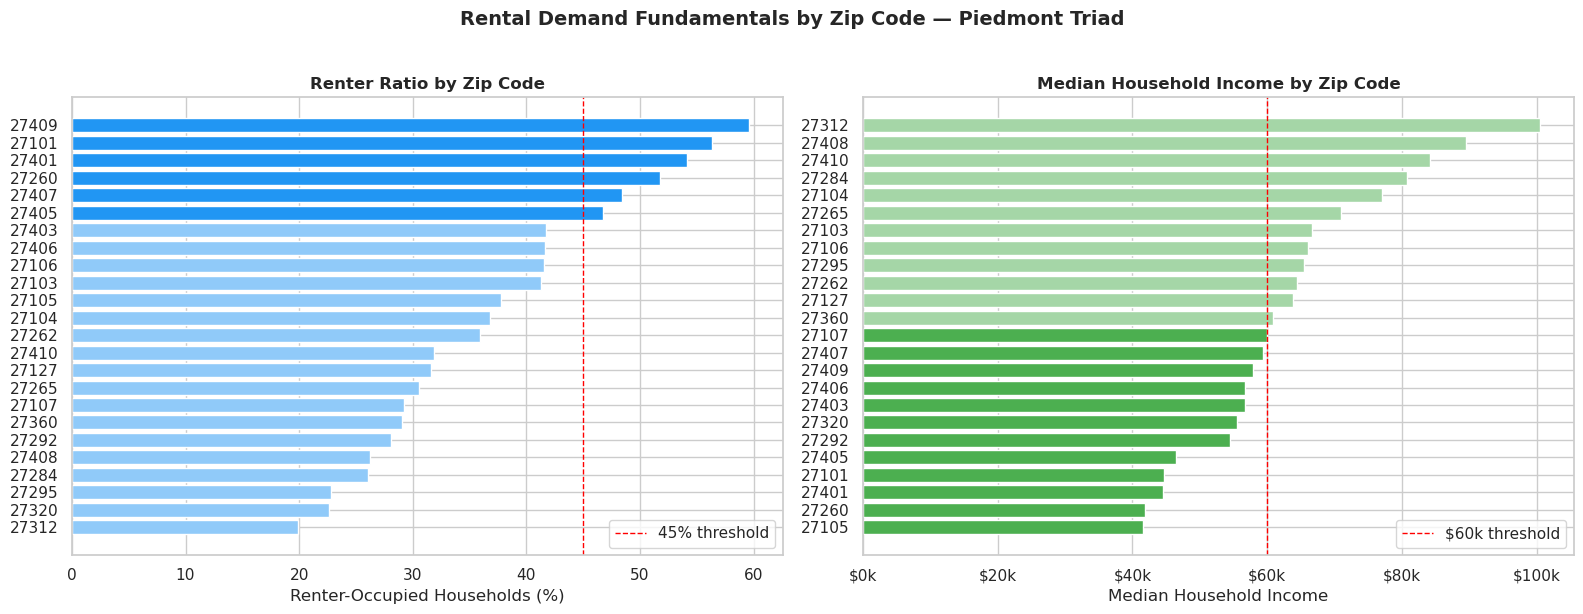

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort by renter ratio for readability
df_sorted_renter = df_macro.sort_values("renter_ratio", ascending=True)

# ── Chart 1: Renter ratio by zip ──────────────────────────────────────────
axes[0].barh(
    df_sorted_renter["zipCode"],
    df_sorted_renter["renter_ratio"] * 100,
    color=["#2196F3" if r > 0.45 else "#90CAF9" 
           for r in df_sorted_renter["renter_ratio"]]
)
axes[0].axvline(x=45, color="red", linestyle="--", linewidth=1, 
                label="45% threshold")
axes[0].set_xlabel("Renter-Occupied Households (%)")
axes[0].set_title("Renter Ratio by Zip Code", fontweight="bold")
axes[0].legend()

# ── Chart 2: Median household income by zip ───────────────────────────────
df_sorted_income = df_macro.sort_values("median_household_income", ascending=True)

axes[1].barh(
    df_sorted_income["zipCode"],
    df_sorted_income["median_household_income"],
    color=["#4CAF50" if i < 60000 else "#A5D6A7" 
           for i in df_sorted_income["median_household_income"]]
)
axes[1].axvline(x=60000, color="red", linestyle="--", linewidth=1,
                label="$60k threshold")
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)
axes[1].set_xlabel("Median Household Income")
axes[1].set_title("Median Household Income by Zip Code", fontweight="bold")
axes[1].legend()

plt.suptitle("Rental Demand Fundamentals by Zip Code — Piedmont Triad", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("renter_ratio_income.png", bbox_inches="tight", dpi=150)
plt.show()

**Findings:** Five zip codes exceed the 45% renter threshold that signals 
strong buy-to-rent demand: 27409, 27101, 27401, 27260, and 27407. Notably, 
27409 (northwest Greensboro, near the airport and industrial corridor) leads 
the market at approximately 60% renter-occupied households — exceptionally 
high and indicative of a workforce rental market. 27101 (downtown Winston-Salem) 
and 27401 (downtown Greensboro) also show strong renter demand above 55%.

On the income side, the same high-renter zip codes tend to fall below the 
60k USD median income threshold — 27401, 27260, and 27105 are among the lowest 
at under 50k USD median income. This combination of high renter ratio and moderate 
income is the classic buy-to-rent profile: strong demand for affordable rentals 
from a workforce that is unlikely to transition to homeownership in the near term. 
Zip codes like 27312 and 27408, by contrast, show high incomes but low renter 
ratios — more competitive owner-occupant markets less suited to rental strategy.

For a small investor targeting buy-to-rent, **27409, 27401, and 27407** emerge 
as the strongest candidates based on demand fundamentals alone.

#### Housing Supply and Market Velocity

Total listing inventory and days on market together indicate how competitive 
a zip code is. High inventory with long days on market gives investors more 
negotiating leverage — a key advantage for fix-and-flip buyers who need to 
acquire below market value.

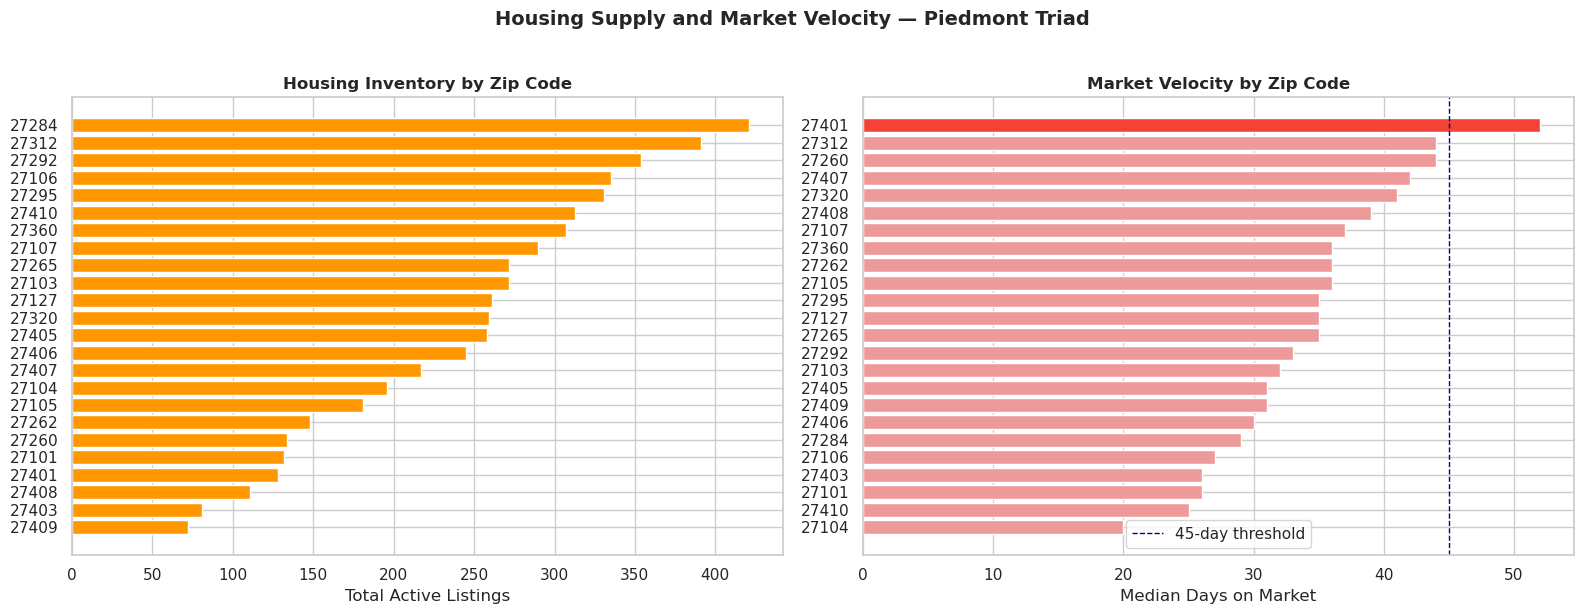

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_sorted_supply = df_macro.sort_values("totalListings", ascending=True)
df_sorted_dom    = df_macro.sort_values("medianDaysOnMarket", ascending=True)

# ── Chart 1: Total listings (inventory) by zip ────────────────────────────
axes[0].barh(
    df_sorted_supply["zipCode"],
    df_sorted_supply["totalListings"],
    color="#FF9800"
)
axes[0].set_xlabel("Total Active Listings")
axes[0].set_title("Housing Inventory by Zip Code", fontweight="bold")

# ── Chart 2: Median days on market by zip ────────────────────────────────
axes[1].barh(
    df_sorted_dom["zipCode"],
    df_sorted_dom["medianDaysOnMarket"],
    color=["#F44336" if d > 45 else "#EF9A9A" 
           for d in df_sorted_dom["medianDaysOnMarket"]]
)
axes[1].axvline(x=45, color="navy", linestyle="--", linewidth=1,
                label="45-day threshold")
axes[1].set_xlabel("Median Days on Market")
axes[1].set_title("Market Velocity by Zip Code", fontweight="bold")
axes[1].legend()

plt.suptitle("Housing Supply and Market Velocity — Piedmont Triad",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("supply_dom.png", bbox_inches="tight", dpi=150)
plt.show()

**Findings:** Housing inventory is highest in suburban and outlying zip codes — 
27284 (Kernersville), 27312, and 27292 (Lexington) lead with over 350 active 
listings each. Interestingly, the high-renter-demand zips identified earlier 
(27409, 27401, 27403) have among the lowest inventory, under 150 listings. 
This supply-demand imbalance is a positive signal for investors — low supply 
in high-demand areas supports both rental occupancy rates and long-term 
price appreciation.

On market velocity, only 27401 exceeds the 45-day median DOM threshold at 
approximately 51 days — every other zip code moves faster than 45 days. 
This is a relatively competitive market overall, but 27401's longer DOM 
combined with its high renter ratio and low inventory creates an interesting 
dynamic: properties are staying on the market longer, potentially giving 
investors more room to negotiate, in a zip code with strong underlying 
rental demand. For fix-and-flip investors, faster-moving markets like 27104 
and 27410 (under 25 days median DOM) signal strong buyer demand that 
supports a quicker exit after renovation.

#### Housing Stock Composition by Property Type

Understanding the mix of property types in each zip code helps investors 
identify markets dominated by single-family homes — the primary target for 
fix-and-flip and buy-to-rent strategies — versus condo-heavy or 
townhome-heavy markets that carry different financing and management dynamics.

Listings by property type (all zips combined):
 propertyType  totalListings
Single Family           4203
         Land            592
    Townhouse            533
        Condo            297
 Manufactured             71
 Multi-Family             12
    Apartment              1


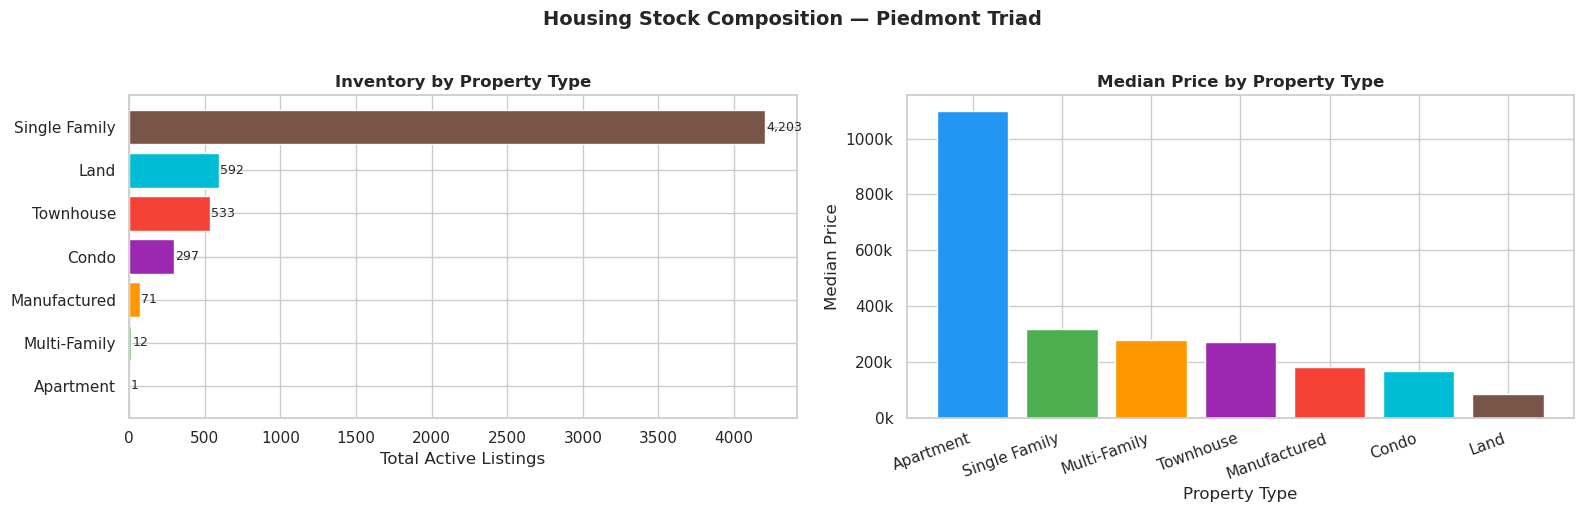

In [46]:
# Unpack the nested dataByPropertyType column
property_type_records = []

for _, row in df_macro.iterrows():
    zip_code = row["zipCode"]
    prop_data = row["dataByPropertyType"]

    if not isinstance(prop_data, list):
        continue

    for entry in prop_data:
        property_type_records.append({
            "zipCode":       zip_code,
            "propertyType":  entry.get("propertyType"),
            "avgPrice":      entry.get("averagePrice"),
            "medianPrice":   entry.get("medianPrice"),
            "totalListings": entry.get("totalListings", 0),
        })

df_prop_types = pd.DataFrame(property_type_records)

# Aggregate total listings by property type across all zips
type_summary = (
    df_prop_types.groupby("propertyType")["totalListings"]
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)

print("Listings by property type (all zips combined):")
print(type_summary.sort_values("totalListings", ascending=False).to_string(index=False))

# ── Charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336", "#00BCD4", "#795548"]

# Horizontal bar chart — inventory by type (replaces pie)
axes[0].barh(
    type_summary["propertyType"],
    type_summary["totalListings"],
    color=colors[:len(type_summary)]
)
axes[0].set_xlabel("Total Active Listings")
axes[0].set_title("Inventory by Property Type", fontweight="bold")

# Add value labels on bars
for i, (val, label) in enumerate(zip(type_summary["totalListings"], 
                                      type_summary["propertyType"])):
    axes[0].text(val + 10, i, f"{val:,}", va="center", fontsize=9)

# Bar chart — median price by property type
type_price = (
    df_prop_types.groupby("propertyType")["medianPrice"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

axes[1].bar(
    type_price["propertyType"],
    type_price["medianPrice"],
    color=colors[:len(type_price)]
)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")
)
axes[1].set_xlabel("Property Type")
axes[1].set_ylabel("Median Price")
axes[1].set_title("Median Price by Property Type", fontweight="bold")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha="right")

plt.suptitle("Housing Stock Composition — Piedmont Triad",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("property_types.png", bbox_inches="tight", dpi=150)
plt.show()

**Findings:** Single-family homes overwhelmingly dominate the Piedmont Triad 
market at 73.6% of all inventory (4,203 listings), confirming this is 
primarily a single-family market — ideal for our target investor. Townhouses 
(533) and condos (297) represent meaningful secondary segments but at 
significantly lower volumes. Notably, only 12 multi-family listings exist 
across all zip codes, suggesting that small multi-family (duplex/triplex) 
opportunities are scarce and highly competitive when they do appear.

On pricing, the single-family median sits around 300k — well within small 
investor acquisition range at current financing rates. Manufactured homes 
median near 180k represent the lowest entry point in the market and may 
appeal to investors targeting the most affordable rental tier.

#### Multivariate Market Comparison: Price vs Income vs Renter Demand

Combining median listing price, median household income, and renter ratio 
into a single view allows us to identify zip codes that sit at the 
intersection of affordable entry prices, moderate incomes, and strong 
rental demand — the sweet spot for buy-to-rent investors.

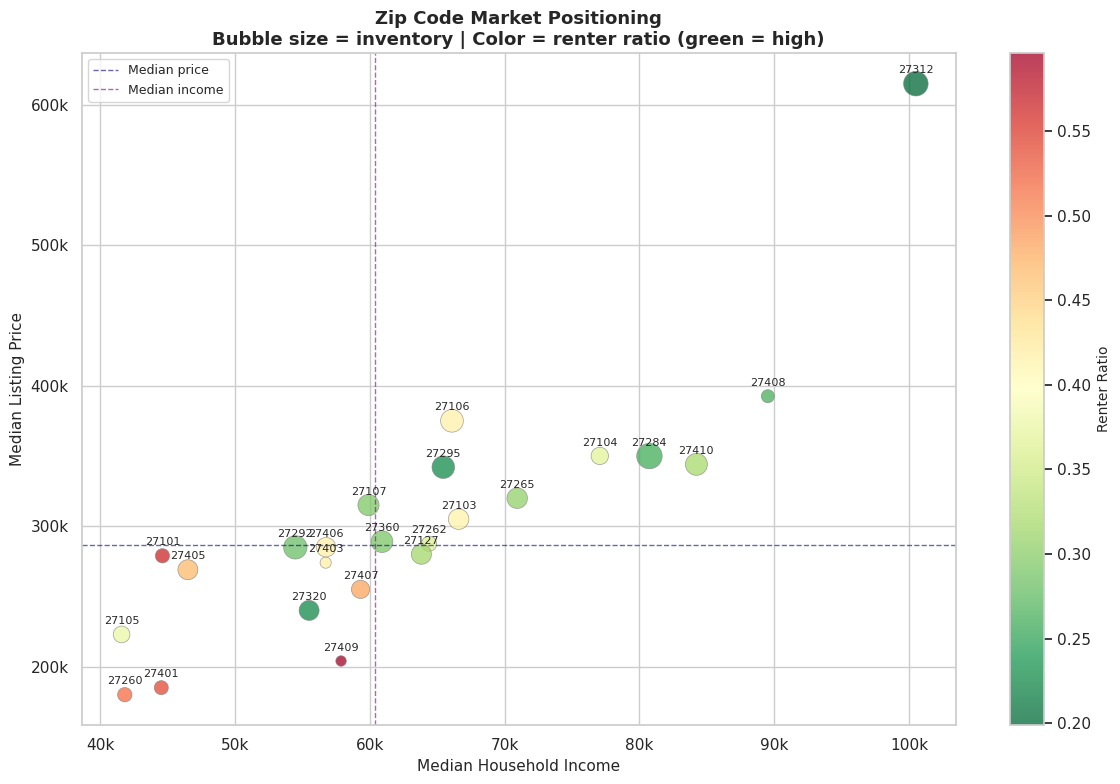

In [47]:
fig, ax = plt.subplots(figsize=(12, 8))

# Bubble size = total listings (inventory signal)
# Color = renter ratio (demand signal)
# X = median household income
# Y = median listing price

scatter = ax.scatter(
    df_macro["median_household_income"],
    df_macro["medianPrice"],
    s=df_macro["totalListings"] * 0.8,
    c=df_macro["renter_ratio"],
    cmap="RdYlGn_r",
    alpha=0.75,
    edgecolors="grey",
    linewidths=0.5
)

# Label each bubble with zip code
for _, row in df_macro.iterrows():
    ax.annotate(
        row["zipCode"],
        (row["median_household_income"], row["medianPrice"]),
        fontsize=8,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points"
    )

# Colorbar for renter ratio
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Renter Ratio", fontsize=10)

# Reference lines
ax.axhline(y=df_macro["medianPrice"].median(), color="navy",
           linestyle="--", linewidth=1, alpha=0.6, label="Median price")
ax.axvline(x=df_macro["median_household_income"].median(), color="purple",
           linestyle="--", linewidth=1, alpha=0.6, label="Median income")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.set_xlabel("Median Household Income", fontsize=11)
ax.set_ylabel("Median Listing Price", fontsize=11)
ax.set_title(
    "Zip Code Market Positioning\n"
    "Bubble size = inventory | Color = renter ratio (green = high)",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("market_scatter.png", bbox_inches="tight", dpi=150)
plt.show()

**Findings:** The bottom-left quadrant — below median price and below median 
income — reveals the most compelling buy-to-rent opportunities. Four zip codes 
stand out here: 27401 and 27260 (downtown Greensboro) both show red-to-orange 
coloring indicating high renter ratios above 50%, with median prices well below 
300k. These are workforce rental markets where entry prices are accessible and 
demand is structurally strong.

27409 is particularly notable — it sits at the lowest median price in the 
entire dataset (around 200k) with the highest renter ratio in the market 
(approximately 60%), yet falls near the median income line. This combination 
suggests a market where residents can afford rent but not homeownership — 
the ideal structural condition for a buy-to-rent investor.

By contrast, the upper-right quadrant (27312, 27408, 27410) shows high-income, 
high-price markets with low renter ratios — owner-occupant territory where 
investor competition is highest and rental yields are typically compressed.

27320 (Reidsville) and 27105 present an interesting middle case — below median 
price with moderate renter ratios — worth watching as secondary targets if 
primary zip codes prove too competitive.

SQL analysis (Q9) decomposes the high-renter-zip cluster visible in this scatter 
into four discrete rental investment profiles. Zip 27409 represents stable 
middle-income condo inventory (59.6% renters, 57.9k income, 36 listings under 
250k averaging 114k–170k). Zip 27401 represents the urban downtown profile 
(54.2% renters, 44.5k income, condos 130k–140k). Zip 27260 in High Point is 
the working-class single-family target (40k–60k inventory, 51.7% renters, 
$41.8k income). Zip 27407 offers a balanced condo plus single-family mix. A 
small investor would choose one profile based on capital constraints, target 
return horizon, and willingness to manage multifamily complexity.

### 3.2 Listing-Level Analysis: Identifying Undervalued Properties

With market-level context established, we now drill into individual listings 
to identify properties that appear undervalued relative to their zip code 
benchmarks. This is the core decision tool for our target investor — 
a small residential investor evaluating whether a specific listed property 
represents a genuine opportunity.

We focus on Greensboro and High Point where we have statistically meaningful 
listing samples (695 and 257 listings respectively after cleaning).

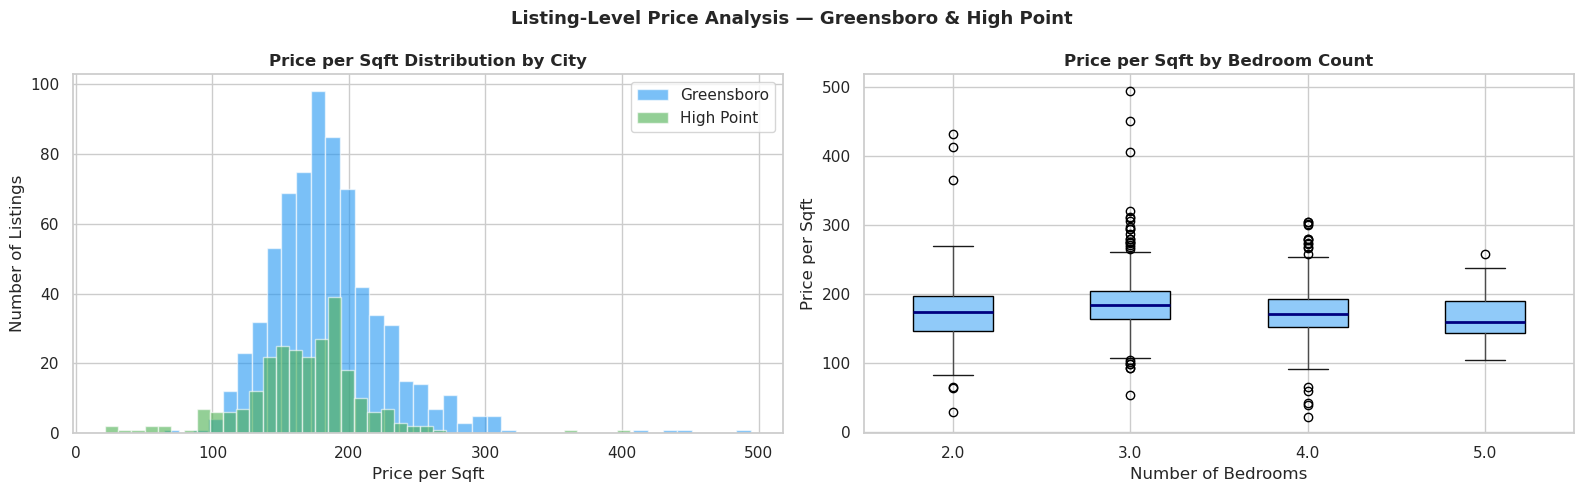


Price per sqft summary:
            count    mean    std    min     25%     50%     75%    max
city                                                                  
Greensboro  695.0  185.12  43.36  64.42  158.62  181.34  203.59  494.3
High Point  257.0  167.25  44.24  21.47  145.01  170.19  191.96  405.6


In [48]:
# Calculate price per square foot — the fundamental valuation metric
df_invest["price_per_sqft"] = df_invest["price"] / df_invest["squareFootage"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: Price per sqft distribution by city ──────────────────────────
for city, color in zip(["Greensboro", "High Point"], ["#2196F3", "#4CAF50"]):
    subset = df_invest[df_invest["city"] == city]["price_per_sqft"]
    axes[0].hist(subset, bins=40, alpha=0.6, label=city, color=color)

axes[0].set_xlabel("Price per Sqft")
axes[0].set_ylabel("Number of Listings")
axes[0].set_title("Price per Sqft Distribution by City", fontweight="bold")
axes[0].legend()

# ── Chart 2: Price per sqft by bedroom count ──────────────────────────────
bedroom_groups = df_invest[df_invest["bedrooms"].isin([2, 3, 4, 5])]
bedroom_groups.boxplot(
    column="price_per_sqft",
    by="bedrooms",
    ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor="#90CAF9"),
    medianprops=dict(color="navy", linewidth=2)
)
axes[1].set_xlabel("Number of Bedrooms")
axes[1].set_ylabel("Price per Sqft")
axes[1].set_title("Price per Sqft by Bedroom Count", fontweight="bold")
plt.suptitle("")  # remove auto-generated title from boxplot

plt.suptitle("Listing-Level Price Analysis — Greensboro & High Point",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("price_per_sqft.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"\nPrice per sqft summary:")
print(df_invest.groupby("city")["price_per_sqft"].describe().round(2).to_string())

**Findings:** Both cities show a right-skewed price per sqft distribution 
centered between 150 and 200 per sqft, consistent with an affordable 
mid-market. Greensboro commands a slight premium at a median of 181 per sqft 
versus High Point's 170 per sqft — a roughly 6% difference that likely 
reflects Greensboro's larger urban core and proximity to employment centers.

Both distributions show a long right tail with outliers above 300 per sqft — 
these are likely renovated or premium properties in desirable neighborhoods 
and represent the post-renovation target price point for fix-and-flip investors.

The bedroom analysis reveals a counterintuitive but investor-relevant insight: 
3-bedroom homes show slightly higher price per sqft than 2, 4, or 5-bedroom 
homes. This is consistent with market research showing 3-bedroom homes command 
a demand premium — they appeal to the widest tenant pool (families, roommates, 
young professionals) making them the optimal fix-and-flip and buy-to-rent target.

SQL analysis (Q12) quantifies the concentration difference. High Point is 
essentially a single-product market at 82.1% single-family share, with townhouse 
(12.1%), condo (5.1%), and land/manufactured rounding out the remainder. 
Investors choosing High Point are effectively choosing between specific detached 
houses. Greensboro is more diversified (66.6% single-family, 20.9% townhouse, 
12.1% condo, with multifamily and manufactured combined under 1%), opening up 
strategy choices based on management complexity preference and rental yield 
profile.

#### Correlation Analysis: What Drives Listing Price?

Understanding which property attributes most strongly correlate with price 
helps investors identify where renovation dollars have the highest return, 
and which features to prioritize when evaluating acquisition targets.

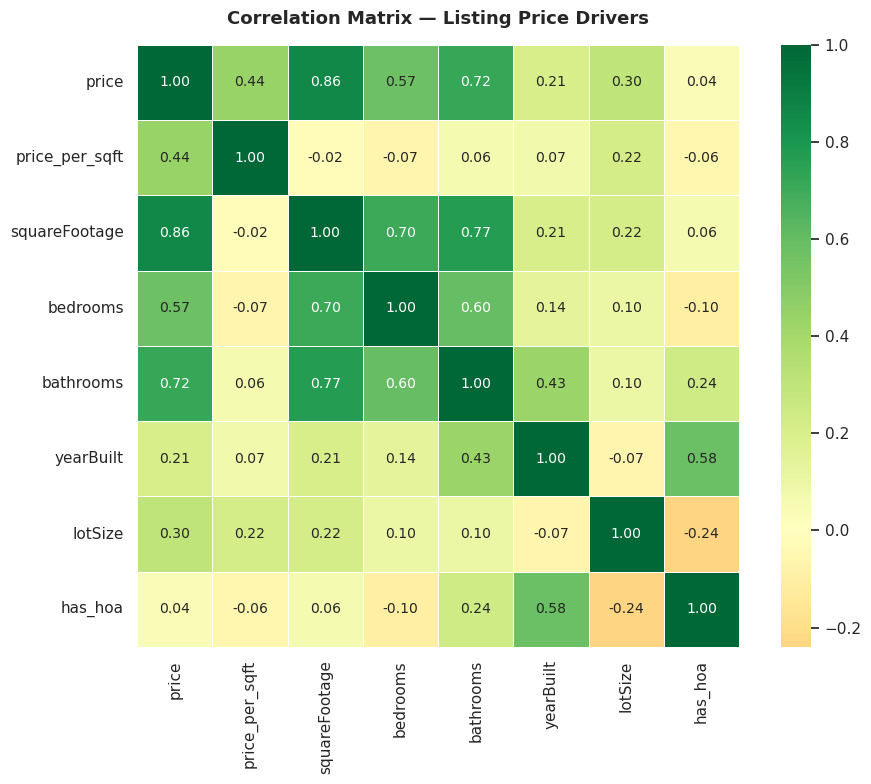

In [49]:
# Select numeric columns relevant to price drivers
corr_cols = [
    "price", "price_per_sqft", "squareFootage", "bedrooms",
    "bathrooms", "yearBuilt", "lotSize", "has_hoa"
]

# Compute correlation matrix on available columns
available_cols = [c for c in corr_cols if c in df_invest.columns]
corr_matrix = df_invest[available_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 10}
)

ax.set_title("Correlation Matrix — Listing Price Drivers",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

**Findings:** Square footage is the single strongest driver of listing price 
at 0.86 correlation — meaning size explains the vast majority of price 
variation in this market. This is a critical insight for fix-and-flip 
investors: adding livable square footage (finishing a basement, adding a 
room) is likely the highest-return renovation in this market.

Bathrooms show a surprisingly strong 0.72 correlation with price — stronger 
than bedrooms (0.57). This aligns with renovation best practices: adding or 
upgrading bathrooms typically yields higher returns than adding bedrooms alone. 
The 0.77 correlation between bathrooms and sqft also suggests that larger 
homes naturally have more bathrooms, but the independent price relationship 
with bathrooms is meaningful.

Notably, price_per_sqft shows near-zero correlation with squareFootage (-0.02), 
confirming that the market prices larger and smaller homes consistently on a 
per-sqft basis — there is no size premium or discount. This makes price per 
sqft a reliable cross-property comparison metric for our valuation analysis.

yearBuilt has a strong 0.58 correlation with has_hoa — newer homes are much 
more likely to have HOA fees, which is a carrying cost investors must factor 
into cash flow projections. HOA presence has minimal correlation with price 
(0.04), suggesting the market does not reward HOA communities with a price 
premium in this region.

SQL per-city ranking by price-per-sqft (Q7) reinforces the case for per-city 
normalization in feature engineering. High Point's ten cheapest-per-sqft 
listings range USD 21–91/sqft, while Greensboro's range USD 64–112/sqft — roughly 
a USD 50/sqft gap between the two cities' value floors. Without per-city 
normalization, score-based ranking would systematically advantage High Point 
listings simply because the price floor is lower there, rather than because 
they offer better value within their submarket.

## Phase 4: Feature Engineering

We engineer new features that transform raw listing attributes into 
investor-relevant signals. These derived metrics form the foundation 
of our undervaluation scoring model — a composite tool that helps 
small investors quickly identify the most promising acquisition targets.

In [50]:
# ── Merge zip-level median price into listings ────────────────────────────
zip_medians = df_invest.groupby("zipCode")["price"].median().rename("zip_median_price")
df_invest = df_invest.merge(zip_medians, on="zipCode", how="left")

# ── Merge census income into listings ─────────────────────────────────────
df_invest = df_invest.merge(
    df_census[["zipCode", "median_household_income"]],
    on="zipCode", how="left"
)

# ── Engineer features ──────────────────────────────────────────────────────

# Price deviation from zip median (negative = listed below median = potential value)
df_invest["price_vs_zip_median_pct"] = (
    (df_invest["price"] - df_invest["zip_median_price"])
    / df_invest["zip_median_price"] * 100
).round(2)

# Property age
df_invest["age"] = 2026 - df_invest["yearBuilt"]

# Age flag — pre-1980 properties have higher renovation potential
df_invest["age_flag"] = (df_invest["yearBuilt"] < 1980).astype(int)

# Bath-to-bed ratio — low ratio signals renovation upside
df_invest["bath_bed_ratio"] = (
    df_invest["bathrooms"] / df_invest["bedrooms"]
).round(2)

# Affordability ratio — price relative to local income
df_invest["affordability_ratio"] = (
    df_invest["price"] / df_invest["median_household_income"]
).round(2)

# Normalize price per sqft within each city (0-1 scale)
df_invest["norm_price_per_sqft"] = df_invest.groupby("city")["price_per_sqft"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
).round(4)

print("Engineered features added:")
new_features = [
    "price_per_sqft", "zip_median_price", "price_vs_zip_median_pct",
    "age", "age_flag", "bath_bed_ratio", "affordability_ratio",
    "norm_price_per_sqft"
]
print(df_invest[new_features].describe().round(2).to_string())

Engineered features added:
       price_per_sqft  zip_median_price  price_vs_zip_median_pct     age  age_flag  bath_bed_ratio  affordability_ratio  norm_price_per_sqft
count          952.00            952.00                   952.00  952.00    952.00          952.00               854.00               952.00
mean           180.30         305150.21                    12.35   39.90      0.40            0.74                 5.40                 0.31
std             44.29          72134.18                    55.83   30.87      0.49            0.22                 2.62                 0.11
min             21.47         175000.00                   -78.04    0.00      0.00            0.25                 0.96                 0.00
25%            154.46         269900.00                   -24.19   17.00      0.00            0.62                 3.59                 0.23
50%            178.83         299900.00                     0.00   35.00      0.00            0.67                 5.00        

### 4.2 Investor Opportunity Score

We construct a composite Investor Opportunity Score for each listing by 
combining five signals, each normalized to a 0-1 scale and weighted by 
relevance to small residential investor decision-making:

| Signal | Weight | Rationale |
|---|---|---|
| Price below zip median | 35% | Primary undervaluation signal |
| Low price per sqft (normalized) | 25% | Value per unit of space |
| Pre-1980 construction | 15% | Renovation upside potential |
| Low bath-to-bed ratio | 15% | Cosmetic renovation opportunity |
| High zip renter ratio | 10% | Demand sustainability for buy-to-rent |

A higher score indicates a listing that is relatively underpriced, offers 
renovation upside, and sits in a market with strong rental demand — the 
combination most relevant to our target investor.

In [51]:
# ── Merge zip renter ratio into listings ─────────────────────────────────
df_invest = df_invest.merge(
    df_census[["zipCode", "renter_ratio"]],
    on="zipCode",
    how="left",
    suffixes=("", "_census")
)

# ── Component 1: Price below zip median (higher = more undervalued) ───────
# Invert so that listings priced BELOW median score HIGH
df_invest["score_price"] = 1 - (
    df_invest["norm_price_per_sqft"]
)

# ── Component 2: Low normalized price per sqft ───────────────────────────
df_invest["score_ppsqft"] = 1 - df_invest["norm_price_per_sqft"]

# ── Component 3: Pre-1980 age flag ────────────────────────────────────────
df_invest["score_age"] = df_invest["age_flag"].astype(float)

# ── Component 4: Low bath-bed ratio (capped at 1 for normalization) ───────
bath_min = df_invest["bath_bed_ratio"].min()
bath_max = df_invest["bath_bed_ratio"].max()
df_invest["score_bath"] = 1 - (
    (df_invest["bath_bed_ratio"] - bath_min) / (bath_max - bath_min)
)

# ── Component 5: Zip renter ratio ─────────────────────────────────────────
renter_min = df_invest["renter_ratio"].min()
renter_max = df_invest["renter_ratio"].max()
df_invest["score_renter"] = (
    (df_invest["renter_ratio"] - renter_min) / (renter_max - renter_min)
)

# ── Composite investor score (weighted sum) ───────────────────────────────
df_invest["investor_score"] = (
    0.35 * df_invest["score_price"] +
    0.25 * df_invest["score_ppsqft"] +
    0.15 * df_invest["score_age"] +
    0.15 * df_invest["score_bath"] +
    0.10 * df_invest["score_renter"]
).round(4)

print(f"Investor score summary:")
print(df_invest["investor_score"].describe().round(3).to_string())
print(f"\nScore distribution by city:")
print(df_invest.groupby("city")["investor_score"].describe().round(3).to_string())

Investor score summary:
count    854.000
mean       0.626
std        0.115
min        0.087
25%        0.548
50%        0.624
75%        0.701
max        0.946

Score distribution by city:
            count  mean    std    min    25%    50%    75%    max
city                                                             
Greensboro  612.0  0.64  0.104  0.087  0.575  0.631  0.706  0.946
High Point  242.0  0.59  0.132  0.271  0.486  0.574  0.689  0.925


### 4.3 Investor-Friendly Tier Labels

To make the final output easier to scan, we engineer two additional 
categorical features:

- **`deal_tier`**: Classifies each listing by the magnitude of its model 
  residual from Phase 5 (computed below in code that depends on Model 1). 
  Listings priced significantly below predicted value receive higher tier 
  ratings.

- **`management_complexity`**: Translates property type into the typical 
  management burden a small investor would face. Single-family homes are 
  lowest complexity, multi-family is highest.

These labels turn quantitative outputs into investor-friendly categories 
that map to real decision-making about which listings to pursue.

In [91]:
# --- Apply: compute deal_tier from model residual (row-wise logic) ---
# Note: this depends on residuals from Model 1 (Phase 5), so this cell must
# run AFTER Model 1 is fit. The residuals are stored in df_model_with_residuals.

def classify_deal_tier(row):
    """Assign a deal tier based on the listing's residual from Model 1.
    
    Tier A: residual <= -$100k (strongly underpriced relative to prediction)
    Tier B: -$100k < residual <= -$30k (modestly underpriced)
    Tier C: -$30k < residual <= $30k (priced as expected)
    Tier D: residual > $30k (priced above prediction)
    """
    r = row["residual"]
    if r <= -100000:
        return "A — strongly underpriced"
    elif r <= -30000:
        return "B — modestly underpriced"
    elif r <= 30000:
        return "C — priced as expected"
    else:
        return "D — priced above prediction"

df_model_with_residuals["deal_tier"] = df_model_with_residuals.apply(
    classify_deal_tier, axis=1
)

# --- Map: translate propertyType into management complexity ---
complexity_map = {
    "Single Family": "Low",
    "Townhouse": "Low",
    "Condo": "Medium",
    "Manufactured": "Medium",
    "Land": "Medium",
    "Multi-Family": "High",
}

df_model_with_residuals["management_complexity"] = (
    df_model_with_residuals["propertyType"].map(complexity_map)
)

# Verify the new columns
print("Deal tier distribution:")
print(df_model_with_residuals["deal_tier"].value_counts().sort_index())

print("\nManagement complexity distribution:")
print(df_model_with_residuals["management_complexity"].value_counts())

# Show a sample with both new columns
print("\nSample of listings with new tier labels:")
sample_cols = ["price", "predicted_price", "residual", "deal_tier",
               "propertyType", "management_complexity"]
print(df_model_with_residuals[sample_cols].head(8).to_string())

Deal tier distribution:
deal_tier
A — strongly underpriced        43
B — modestly underpriced       224
C — priced as expected         349
D — priced above prediction    203
Name: count, dtype: int64

Management complexity distribution:
management_complexity
Low       736
Medium     82
High        1
Name: count, dtype: int64

Sample of listings with new tier labels:
    price  predicted_price  residual                    deal_tier   propertyType management_complexity
1  565000         538032.0   26968.0       C — priced as expected  Single Family                   Low
2  236000         245032.0   -9032.0       C — priced as expected  Single Family                   Low
3  441450         318432.0  123018.0  D — priced above prediction          Condo                Medium
4  385000         288339.0   96661.0  D — priced above prediction          Condo                Medium
5  145000         202963.0  -57963.0     B — modestly underpriced  Single Family                   Low
6  525000    

### 4.4 Top Investment Opportunities

The listings with the highest investor scores represent the most compelling 
acquisition targets based on our composite model — properties that are 
underpriced relative to their zip code, offer renovation upside, and sit 
in markets with strong rental demand.

TOP 15 INVESTMENT OPPORTUNITIES — PIEDMONT TRIAD
                                 formattedAddress       city zipCode   price  bedrooms  bathrooms  squareFootage  yearBuilt price_per_sqft price_vs_zip_median_pct  investor_score
           523 W Terrell St, Greensboro, NC 27406 Greensboro   27406 128,000       4.0        1.0         1987.0     1927.0             64                  -57.3%          0.9462
          808 Cliffside Ave, High Point, NC 27260 High Point   27260  55,000       4.0        2.0         1440.0     1956.0             38                  -69.4%          0.9253
           713 Langford Ave, High Point, NC 27260 High Point   27260  60,000       4.0        2.0         1428.0     1964.0             42                  -66.7%          0.9193
    1101 N Elm St, Unit 802, Greensboro, NC 27401 Greensboro   27401 129,900       3.0        2.0         1398.0     1963.0             93                  -36.6%          0.9019
              517 Flint Ave, High Point, NC 27260 High P

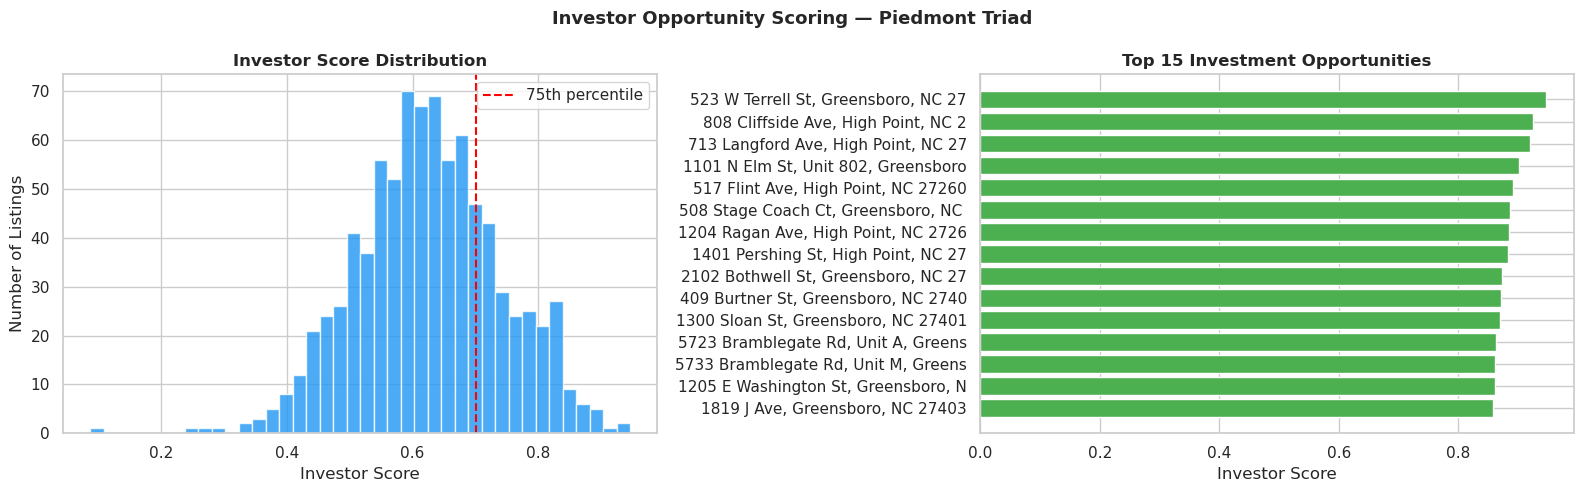

In [52]:
# Top 15 opportunities
display_cols = [
    "formattedAddress", "city", "zipCode", "price", "bedrooms",
    "bathrooms", "squareFootage", "yearBuilt", "price_per_sqft",
    "price_vs_zip_median_pct", "investor_score"
]

top_opportunities = (
    df_invest[display_cols]
    .sort_values("investor_score", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

# Format for display
top_opportunities["price"] = top_opportunities["price"].apply(lambda x: f"{x:,.0f}")
top_opportunities["price_per_sqft"] = top_opportunities["price_per_sqft"].apply(lambda x: f"{x:.0f}")
top_opportunities["price_vs_zip_median_pct"] = top_opportunities["price_vs_zip_median_pct"].apply(lambda x: f"{x:.1f}%")

print("TOP 15 INVESTMENT OPPORTUNITIES — PIEDMONT TRIAD")
print("=" * 80)
print(top_opportunities.to_string(index=False))

# ── Visualize score distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Score distribution
df_invest["investor_score"].hist(bins=40, ax=axes[0], color="#2196F3", alpha=0.8)
axes[0].axvline(df_invest["investor_score"].quantile(0.75), color="red",
                linestyle="--", label="75th percentile")
axes[0].set_xlabel("Investor Score")
axes[0].set_ylabel("Number of Listings")
axes[0].set_title("Investor Score Distribution", fontweight="bold")
axes[0].legend()

# Top 15 scores bar chart
top_15 = df_invest.nlargest(15, "investor_score")
axes[1].barh(
    top_15["formattedAddress"].str[:35],
    top_15["investor_score"],
    color="#4CAF50"
)
axes[1].set_xlabel("Investor Score")
axes[1].set_title("Top 15 Investment Opportunities", fontweight="bold")
axes[1].invert_yaxis()

plt.suptitle("Investor Opportunity Scoring — Piedmont Triad",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("investor_scores.png", bbox_inches="tight", dpi=150)
plt.show()

**Findings:** The investor score distribution is roughly normal, centered around 
0.62, with the top opportunities clearly separated above the 75th percentile 
threshold (0.70). This confirms that genuine outlier opportunities exist in 
the market — they're not evenly distributed.

Greensboro outperforms High Point on average (mean score 0.64 vs 0.59), 
reflecting its higher concentration of older workforce housing in high-renter 
zip codes. The top-scoring property — 523 W Terrell St in zip 27406 — is a 
4-bedroom, 1927-built home listed at 128,000, a remarkable 57% below its zip 
median. At 64 per sqft it represents extraordinary value relative to the market.

High Point's 27260 zip code dominates the top 15 with four entries, all 
priced between 40,000 and 80,000 — suggesting a pocket of the market with 
significant distressed inventory that warrants closer inspection. These properties 
have the renovation upside profile (pre-1960 construction, low price per sqft) 
that fix-and-flip investors actively seek.

One notable outlier in the top 15 is 508 Stage Coach Ct in 27409 — priced at 
350,000 and actually 67.5% above its zip median, yet scoring high due to its 
large square footage (3,196 sqft), pre-1963 construction, and 27409's 
exceptional renter ratio. This illustrates an important caveat: the score 
reflects multiple investor signals simultaneously, and investors should always 
review individual property details before making acquisition decisions.

## Phase 5: Predictive Modeling

The midterm built a heuristic composite score to rank investment opportunities. 
The final extends this with two statistical models that test and complement the 
heuristic approach.

**Model 1 — Linear regression predicting listing price.** Given each listing's 
attributes and neighborhood context, the model predicts what the price should 
be. The residual (actual − predicted) provides a statistical definition of 
undervaluation — listings priced significantly below their predicted value are 
candidates for further investigation.

**Model 2 — Logistic regression classifying "deal" status.** Using Model 1's 
residuals, we define listings in the bottom 25% (most underpriced relative to 
prediction) as "deals" and ask which features best predict deal status. This 
allows direct comparison against the hand-picked weights used in the midterm 
heuristic.

In [75]:
# Build the modeling dataset from df_invest
# Select features we'll use for both models
feature_cols = [
    "squareFootage",
    "bedrooms",
    "bathrooms",
    "age",
    "lotSize",
    "median_household_income",
    "renter_ratio",
    "has_hoa",
    "city",
    "propertyType",
]

# Drop rows with missing values in any modeling feature or the target
df_model = df_invest[feature_cols + ["price"]].dropna()

print(f"Modeling dataset: {len(df_model)} listings after dropping missing values")
print(f"Original df_invest: {len(df_invest)} listings")
print(f"Dropped: {len(df_invest) - len(df_model)} listings due to missing values")

Modeling dataset: 819 listings after dropping missing values
Original df_invest: 952 listings
Dropped: 133 listings due to missing values


In [76]:
# Convert categorical columns to dummy variables
# drop_first=True drops one category per variable to avoid multicollinearity
df_model_encoded = pd.get_dummies(
    df_model,
    columns=["city", "propertyType"],
    drop_first=True,
    dtype=int
)

print(f"Columns before encoding: {len(df_model.columns)}")
print(f"Columns after encoding: {len(df_model_encoded.columns)}")
print("\nNew columns created:")
print([c for c in df_model_encoded.columns if c not in df_model.columns])

Columns before encoding: 11
Columns after encoding: 15

New columns created:
['city_High Point', 'propertyType_Land', 'propertyType_Manufactured', 'propertyType_Multi-Family', 'propertyType_Single Family', 'propertyType_Townhouse']


In [77]:
# Separate features (X) from target (y)
X = df_model_encoded.drop(columns=["price"])
y = df_model_encoded["price"]

# Split into training and test sets
# 80% train, 20% test, with a fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} listings")
print(f"Test set:     {len(X_test)} listings")
print(f"\nFeatures used in model ({len(X.columns)}):")
for col in X.columns:
    print(f"  - {col}")

Training set: 655 listings
Test set:     164 listings

Features used in model (14):
  - squareFootage
  - bedrooms
  - bathrooms
  - age
  - lotSize
  - median_household_income
  - renter_ratio
  - has_hoa
  - city_High Point
  - propertyType_Land
  - propertyType_Manufactured
  - propertyType_Multi-Family
  - propertyType_Single Family
  - propertyType_Townhouse


In [78]:
# Fit the linear regression on the training set
model_1 = LinearRegression()
model_1.fit(X_train, y_train)

# Generate predictions for both train and test sets
y_train_pred = model_1.predict(X_train)
y_test_pred = model_1.predict(X_test)

# Compute metrics on the test set (the honest evaluation)
test_r2   = r2_score(y_test, y_test_pred)
test_mse  = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae  = mean_absolute_error(y_test, y_test_pred)

# Compute metrics on the train set (for comparison)
train_r2   = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Adjusted R-squared formula for the test set
n = len(y_test)
p = X_test.shape[1]
test_adj_r2 = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)

# Display results
print("=" * 55)
print("MODEL 1 — LINEAR REGRESSION: PRICE PREDICTION")
print("=" * 55)
print(f"\nTraining set performance:")
print(f"  R²:           {train_r2:.4f}")
print(f"  RMSE:         ${train_rmse:,.0f}")
print(f"\nTest set performance:")
print(f"  R²:           {test_r2:.4f}")
print(f"  Adjusted R²:  {test_adj_r2:.4f}")
print(f"  MSE:          {test_mse:,.0f}")
print(f"  RMSE:         ${test_rmse:,.0f}")
print(f"  MAE:          ${test_mae:,.0f}")

MODEL 1 — LINEAR REGRESSION: PRICE PREDICTION

Training set performance:
  R²:           0.7737
  RMSE:         $78,773

Test set performance:
  R²:           0.7797
  Adjusted R²:  0.7590
  MSE:          8,337,809,457
  RMSE:         $91,312
  MAE:          $63,881


In [79]:
# Build a coefficient table showing each feature's contribution
coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model_1.coef_,
    "abs_coefficient": np.abs(model_1.coef_)
}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

# Add a "direction" column for readability
coef_table["direction"] = coef_table["coefficient"].apply(
    lambda x: "positive (↑ price)" if x > 0 else "negative (↓ price)"
)

# Format coefficient column for display
coef_table["coefficient_formatted"] = coef_table["coefficient"].apply(lambda x: f"${x:,.0f}")

# Add intercept as a separate display
intercept_value = model_1.intercept_
print(f"Model intercept: ${intercept_value:,.0f}")
print("(Baseline price when all features = 0; not interpretable on its own)\n")

print("=" * 75)
print("FEATURE COEFFICIENTS — sorted by absolute magnitude")
print("=" * 75)

# Display the table (drop the helper column)
coef_display = coef_table[["feature", "coefficient_formatted", "direction"]].copy()
coef_display.columns = ["Feature", "Coefficient", "Direction"]
print(coef_display.to_string(index=False))

Model intercept: $-154,821
(Baseline price when all features = 0; not interpretable on its own)

FEATURE COEFFICIENTS — sorted by absolute magnitude
                   Feature Coefficient          Direction
         propertyType_Land   $-453,772 negative (↓ price)
              renter_ratio     $85,232 positive (↑ price)
 propertyType_Multi-Family    $-72,658 negative (↓ price)
propertyType_Single Family     $51,523 positive (↑ price)
 propertyType_Manufactured    $-46,722 negative (↓ price)
                 bathrooms     $43,530 positive (↑ price)
    propertyType_Townhouse     $34,428 positive (↑ price)
           city_High Point    $-29,916 negative (↓ price)
                  bedrooms    $-18,465 negative (↓ price)
                   has_hoa     $-5,317 negative (↓ price)
                       age        $217 positive (↑ price)
             squareFootage        $138 positive (↑ price)
   median_household_income          $2 positive (↑ price)
                   lotSize          $1 

In [80]:
# Compute residuals across the FULL modeling dataset (not just test set)
# We need predictions on every row to identify underpriced listings everywhere
y_all_pred = model_1.predict(X)
residuals = y - y_all_pred

# Attach predictions and residuals back to df_model for downstream analysis
df_model_with_residuals = df_model.copy()
df_model_with_residuals["predicted_price"] = y_all_pred.round(0)
df_model_with_residuals["residual"] = residuals.round(0)
df_model_with_residuals["residual_pct"] = (residuals / y * 100).round(1)

# Show the 10 most underpriced listings (most negative residuals)
print("=" * 80)
print("TOP 10 STATISTICALLY UNDERPRICED LISTINGS")
print("(Listings priced furthest below what the model predicts they should cost)")
print("=" * 80)

# Pull formattedAddress from df_invest using the index
underpriced = df_model_with_residuals.nsmallest(10, "residual")[
    ["price", "predicted_price", "residual", "residual_pct",
     "squareFootage", "bedrooms", "bathrooms", "city", "propertyType"]
]

print(underpriced.to_string())

TOP 10 STATISTICALLY UNDERPRICED LISTINGS
(Listings priced furthest below what the model predicts they should cost)
      price  predicted_price  residual  residual_pct  squareFootage  bedrooms  bathrooms        city   propertyType
885  549900         852776.0 -302876.0         -55.1         4772.0       3.0        3.5  High Point  Single Family
113  629000         901163.0 -272163.0         -43.3         4936.0       5.0        5.0  Greensboro  Single Family
282  364900         612816.0 -247916.0         -67.9         3623.0       3.0        2.5  Greensboro  Single Family
525  350000         592764.0 -242764.0         -69.4         3196.0       4.0        3.0  Greensboro  Single Family
89   498000         734527.0 -236527.0         -47.5         4398.0       4.0        3.0  Greensboro  Single Family
491  589900         803875.0 -213975.0         -36.3         4509.0       4.0        3.5  Greensboro  Single Family
73   435000         637017.0 -202017.0         -46.4         3251.0     

### Model 1 — Interpretation

The linear regression explains approximately 78% of variation in listing prices 
across the Piedmont Triad using publicly available features. This is a 
defensible result for real estate modeling without condition data, recent 
comparables, or sub-zip location detail.

Three findings warrant emphasis in the investor narrative:

**Property type dominates price formation.** The four property type coefficients 
are the largest in the model. Land parcels are priced approximately USD 454k 
below comparable condos. Single-family homes carry a USD 52k premium over 
comparable condos. This means cross-product comparisons (e.g., comparing a cheap 
condo to a cheap single-family) are inherently misleading — like-for-like 
comparisons require holding property type constant.

**Location matters substantially.** A High Point listing is priced approximately 
USD 30k below an otherwise-identical Greensboro listing. Median household income 
in the zip contributes meaningfully (approximately USD 2 per USD 1 of income, 
which compounds to tens of thousands of dollars across the zip income range).

**Renter ratio carries a positive coefficient** (+USD 85k), which is 
counterintuitive given the conventional wisdom that high-renter zips have 
lower property values. This coefficient likely captures urban-amenity effects 
correlated with renter density rather than rental demand per se, given the 
small number of distinct zip codes in the dataset (24). This is flagged as 
a model limitation.

The model's residuals (actual price minus predicted price) provide a 
statistical definition of undervaluation. Listings with large negative residuals 
are priced significantly below what the model predicts, and these listings 
form the basis for Model 2's binary classification of "deal status."

**Important caveat:** the model has no condition data. Large negative residuals 
may reflect genuine market dislocation or undisclosed property condition issues. 
The residual is a screening signal worth investigating, not a buy recommendation.

### Model 2 — Logistic Regression: Deal Classification

Model 1 produced residuals (actual price − predicted price) for every listing 
in the modeling dataset. Model 2 turns those residuals into a binary 
classification problem: predict whether a listing is in the bottom 25% of 
residuals (most underpriced) based on its features. This lets us identify 
*which features* predict deal status, and directly compare those findings 
against the midterm's hand-picked weights.

In [82]:
# Define "deal" as being in the bottom 25% of residuals (most underpriced)
residual_threshold = df_model_with_residuals["residual"].quantile(0.25)

df_model_with_residuals["is_deal"] = (
    df_model_with_residuals["residual"] <= residual_threshold
).astype(int)

# Verify the split
print(f"Residual threshold for 'deal' status: ${residual_threshold:,.0f}")
print(f"Listings classified as deals: {df_model_with_residuals['is_deal'].sum()}")
print(f"Listings classified as non-deals: {(df_model_with_residuals['is_deal'] == 0).sum()}")
print(f"Deal rate: {df_model_with_residuals['is_deal'].mean() * 100:.1f}%")

Residual threshold for 'deal' status: $-42,228
Listings classified as deals: 205
Listings classified as non-deals: 614
Deal rate: 25.0%


In [83]:
# Build features (X) and target (y) for Model 2
# Drop 'price' because it was used to derive 'is_deal' — including it would leak
X_model2 = df_model_encoded.drop(columns=["price"])
y_model2 = df_model_with_residuals["is_deal"]

# Confirm alignment between X and y
assert len(X_model2) == len(y_model2), "X and y must have the same length"

# Split into training and test sets — same 80/20 split as Model 1
# stratify=y_model2 ensures both train and test have the same 25% deal rate
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_model2, y_model2,
    test_size=0.2,
    random_state=42,
    stratify=y_model2
)

print(f"Training set: {len(X_train2)} listings")
print(f"  Deals in training: {y_train2.sum()} ({y_train2.mean() * 100:.1f}%)")
print(f"Test set:     {len(X_test2)} listings")
print(f"  Deals in test:     {y_test2.sum()} ({y_test2.mean() * 100:.1f}%)")

Training set: 655 listings
  Deals in training: 164 (25.0%)
Test set:     164 listings
  Deals in test:     41 (25.0%)


In [88]:
# Standardize features (mean=0, std=1) before fitting logistic regression
# This is essential when features are on different scales
scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

# Fit the logistic regression on the SCALED training set
model_2 = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
model_2.fit(X_train2_scaled, y_train2)

# Generate predictions on the scaled test set
y_test2_pred = model_2.predict(X_test2_scaled)
y_test2_proba = model_2.predict_proba(X_test2_scaled)[:, 1]

# Compute classification metrics
accuracy = accuracy_score(y_test2, y_test2_pred)
precision = precision_score(y_test2, y_test2_pred, zero_division=0)
recall = recall_score(y_test2, y_test2_pred, zero_division=0)
f1 = f1_score(y_test2, y_test2_pred, zero_division=0)
auc = roc_auc_score(y_test2, y_test2_proba)
conf_matrix = confusion_matrix(y_test2, y_test2_pred)

# Display results
print("=" * 60)
print("MODEL 2 — LOGISTIC REGRESSION: DEAL CLASSIFICATION")
print("=" * 60)
print(f"\nTest set performance:")
print(f"  Accuracy:    {accuracy:.4f}  ({accuracy * 100:.1f}%)")
print(f"  Precision:   {precision:.4f}  (when predicted deal, % actually deals)")
print(f"  Recall:      {recall:.4f}  (of actual deals, % the model caught)")
print(f"  F1 score:    {f1:.4f}  (harmonic mean of precision and recall)")
print(f"  ROC-AUC:     {auc:.4f}  (0.5 = random, 1.0 = perfect)")

print(f"\nConfusion Matrix:")
print(f"                  Predicted")
print(f"                  Non-Deal    Deal")
print(f"  Actual Non-Deal     {conf_matrix[0, 0]:4d}     {conf_matrix[0, 1]:4d}")
print(f"  Actual Deal         {conf_matrix[1, 0]:4d}     {conf_matrix[1, 1]:4d}")

print(f"\n--- Detailed classification report ---")
print(classification_report(y_test2, y_test2_pred,
                            target_names=["Non-Deal", "Deal"],
                            zero_division=0))

MODEL 2 — LOGISTIC REGRESSION: DEAL CLASSIFICATION

Test set performance:
  Accuracy:    0.6890  (68.9%)
  Precision:   0.3958  (when predicted deal, % actually deals)
  Recall:      0.4634  (of actual deals, % the model caught)
  F1 score:    0.4270  (harmonic mean of precision and recall)
  ROC-AUC:     0.6928  (0.5 = random, 1.0 = perfect)

Confusion Matrix:
                  Predicted
                  Non-Deal    Deal
  Actual Non-Deal       94       29
  Actual Deal           22       19

--- Detailed classification report ---
              precision    recall  f1-score   support

    Non-Deal       0.81      0.76      0.79       123
        Deal       0.40      0.46      0.43        41

    accuracy                           0.69       164
   macro avg       0.60      0.61      0.61       164
weighted avg       0.71      0.69      0.70       164



In [89]:
# Build a coefficient table for Model 2
# Coefficients are in standardized units (per 1 standard deviation of the feature)
# Positive coefficient = increases probability of being a deal
# Negative coefficient = decreases probability of being a deal
coef_table_2 = pd.DataFrame({
    "feature": X_train2.columns,
    "coefficient": model_2.coef_[0],
    "abs_coefficient": np.abs(model_2.coef_[0])
}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

# Add a direction column for readability
coef_table_2["direction"] = coef_table_2["coefficient"].apply(
    lambda x: "↑ deal probability" if x > 0 else "↓ deal probability"
)

# Format for display
coef_table_2["coefficient_formatted"] = coef_table_2["coefficient"].apply(lambda x: f"{x:+.3f}")

# Show intercept separately
intercept_2 = model_2.intercept_[0]
print(f"Model intercept (log-odds): {intercept_2:.3f}")
print(f"(Baseline log-odds of being a deal when all features = 0; not directly interpretable)\n")

print("=" * 75)
print("FEATURE COEFFICIENTS — sorted by absolute magnitude")
print("(In standardized units. Larger absolute = more influential.)")
print("=" * 75)

coef_display_2 = coef_table_2[["feature", "coefficient_formatted", "direction"]].copy()
coef_display_2.columns = ["Feature", "Coefficient", "Direction"]
print(coef_display_2.to_string(index=False))

Model intercept (log-odds): -0.127
(Baseline log-odds of being a deal when all features = 0; not directly interpretable)

FEATURE COEFFICIENTS — sorted by absolute magnitude
(In standardized units. Larger absolute = more influential.)
                   Feature Coefficient          Direction
             squareFootage      +0.498 ↑ deal probability
                       age      +0.479 ↑ deal probability
           city_High Point      -0.362 ↓ deal probability
   median_household_income      -0.346 ↓ deal probability
                 bathrooms      +0.332 ↑ deal probability
              renter_ratio      -0.313 ↓ deal probability
 propertyType_Multi-Family      -0.270 ↓ deal probability
                  bedrooms      -0.203 ↓ deal probability
         propertyType_Land      -0.186 ↓ deal probability
                   lotSize      +0.181 ↑ deal probability
    propertyType_Townhouse      +0.138 ↑ deal probability
                   has_hoa      -0.086 ↓ deal probability
propertyTyp

### Model 2 — Interpretation

The logistic regression provides modest but real classification power 
(AUC = 0.69), and importantly, surfaces which features actually predict 
statistical underpricing. Three findings warrant emphasis:

**Size and age are the strongest deal predictors.** Square footage 
(coefficient +0.498) and age (+0.479) are the model's top two features. 
Larger and older homes are systematically more likely to be priced below 
what their attributes predict. This validates the midterm's intuition to 
weight pre-1980 construction (age_flag) at 15% — directionally correct, 
and possibly under-weighted given the model's evidence.

**Renter ratio carries a negative coefficient (−0.313)**, contradicting the 
midterm's positive weighting (10%). The midterm assumed high renter ratio 
indicates good rental demand and therefore strong investment territory. The 
model suggests the opposite: rental-heavy markets are priced more efficiently 
for rental income, leaving less underpricing to exploit. This is a 
meaningful re-interpretation — the midterm was answering "where is rental 
demand?" while the model answers "where is the market mispriced?" These are 
related but distinct questions.

**City effects matter.** Greensboro listings are significantly more likely 
to be deals than High Point listings (coefficient −0.362 for High Point). 
This suggests Greensboro has more pricing inefficiency for the model to 
exploit, even though absolute prices are higher there. For an investor 
with capital, this implies Greensboro deserves more search attention than 
its lower-priced reputation might suggest.

Used as a screening tool, the model flags 48 of 164 test listings as 
potential deals (29 false positives + 19 true positives), achieving a 40% 
hit rate versus the 25% baseline of random selection. It misses 22 of 41 
true deals. This is a useful screen but not a substitute for due diligence —  
many flagged listings will be underpriced for legitimate reasons (condition, 
distress) that the model cannot observe.

## Conclusion

This analysis set out to answer a core question for small residential investors 
in the Piedmont Triad: **which zip codes offer the strongest market fundamentals, 
and which active listings appear undervalued relative to those fundamentals?** 
The final phase additionally asked whether the midterm's heuristic scoring 
intuitions hold up under statistical scrutiny.

### What we found at the market level

Zip codes 27409, 27401, and 27260 emerge as the strongest buy-to-rent candidates, 
combining renter ratios above 45%, median household incomes below USD 50,000, 
and median listing prices well below the regional average. The Piedmont Triad 
is a fundamentally single-family market (73.6% of inventory) with stable 
employment anchored by Toyota, Honda Aircraft, FedEx, and major healthcare 
systems — supporting long-term rental demand at accessible price points.

### What we found at the listing level

952 investment-relevant listings were scored across Greensboro and High Point 
using the midterm's composite Investor Opportunity Score. The top opportunities 
clustered in zip codes 27406 (Greensboro) and 27260 (High Point), featuring 
pre-1960 construction priced 50-77% below their zip medians.

### Key strategic findings from SQL analysis

Supplementary SQL analysis (`sql_queries.ipynb`) surfaces three strategic 
findings that complement the listing-level scoring work:

1. **27260 emerges as the highest-conviction rental territory in the dataset** 
   (Q10). The zip meets both the above-average renter ratio criterion (51.7% 
   versus dataset average) and the below-average median income criterion 
   (USD 41.8k versus dataset average), with 71 listings averaging USD 197k.

2. **Property mix shapes available strategies** (Q12). High Point's 82% 
   single-family concentration means investors there are effectively choosing 
   between detached houses. Greensboro's more balanced mix (66.6% single-family, 
   20.9% townhouse, 12.1% condo) supports multiple investor profiles in the 
   same geography.

3. **Data gap in Winston-Salem is consequential** (Q10). Two zip codes 
   (27101, 27105) that would have qualified on demographic criteria for the 
   rental investment screen were excluded during data quality cleaning.

### What the models added

The linear regression (Model 1) explains 78% of price variation using publicly 
available features, providing a statistical benchmark for "underpriced." The 
logistic regression (Model 2) then asked which features predict statistical 
underpricing — and produced the analytical centerpiece of the final phase: 
a direct test of the midterm's hand-picked weights.

**Two midterm intuitions were confirmed by the model:**
- Age as a deal signal — the model's strongest predictor was square footage 
  (+0.498) closely followed by age (+0.479), validating the midterm's 
  pre-1980 flag.
- Bath-bed ratio — the model's positive bathroom coefficient and negative 
  bedroom coefficient together replicate the midterm's logic that more 
  bathrooms relative to bedrooms signals deal potential.

**One midterm intuition was contradicted by the model:**
- Renter ratio — the midterm assigned +10% weight assuming high renter 
  ratio indicates good investment territory. The model says the opposite: 
  high-renter zips are priced *more* efficiently for rental income, leaving 
  *less* underpricing to exploit. This is the project's most analytically 
  significant finding — the midterm was answering "where is rental demand?" 
  while the model answers "where is the market mispriced?" These are 
  related but distinct questions.

### Updated investor guidance

Combining the heuristic, SQL, and model findings:

- **For buy-and-hold rental investors:** 27260 remains the highest-conviction 
  zip based on demographic fundamentals (Q10), even though the model says 
  the market is more efficiently priced there. Use the heuristic top 15 
  as a screening tool, focusing on Tier A and Tier B listings from the 
  deal_tier classification.
- **For fix-and-flip investors:** Larger, older single-family homes show 
  the most statistical underpricing per Model 1's residuals. Greensboro 
  offers more inefficiency to exploit (model coefficient evidence) than 
  its higher absolute prices might suggest.
- **For both:** The composite Investor Opportunity Score is a screening 
  tool, not a final acquisition recommendation. Investors should conduct 
  full due diligence including property inspections, title searches, and 
  local market comparable analysis before any acquisition decision.

### Limitations and future work

With more time, this analysis would benefit from:

1. **Cap rate integration.** Adding HUD Fair Market Rent data (or actual 
   rental comps) would let us compute estimated rental yields per listing — 
   directly answering investor questions about cash flow.
2. **Property condition data.** Model 1's residuals likely conflate genuine 
   undervaluation with undisclosed condition issues. Condition data 
   (inspections, days since renovation) would sharpen the underpricing 
   signal substantially.
3. **Winston-Salem reintegration.** Re-sourcing Winston-Salem listings 
   with adequate sample would let us evaluate the high-renter, low-income 
   zips (27101, 27105) that Q10 identified but the listings dataset 
   couldn't support.
4. **Neighborhood fundamentals.** School quality ratings and crime indices 
   would explain some of the 22% of price variation Model 1 cannot capture.

The investor opportunity score, residual analysis, and deal classification 
together form a screening framework — not a buy recommendation. Investor 
discretion, in-person due diligence, and local market knowledge remain 
essential to any final acquisition decision.